# metrics

> Metrics in fastai's style for typed decisions: a split's predictions in one `Preds`, a function per metric, `Metric` to bind a metric's arguments, keep it to one kind of question and name it, and a table of metrics by question kind or id. The learner reports them every epoch, and `evaluate` computes them from any backend's answers.

In [ ]:
#| default_exp metrics

In [ ]:
#| export
import inspect, math

import numpy as np
from fastcore.basics import patch

from sysone.core import *
from sysone.losses import ece_score, auroc, coverage_curve, act_metrics

In [ ]:
#| hide
from fastcore.test import test_eq, test_close, test_fail
import json, logging
from pathlib import Path
import torch
logging.getLogger("transformers").setLevel(logging.ERROR)
import datasets, transformers; datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
                     "axes.titlesize": 9, "legend.fontsize": 8, "legend.frameon": False})

In [ ]:
from sysone.losses import decision_metrics, answer_metrics, macro_f1

In fastai, a metric is a function of what the model predicted and what the targets were. A learner takes a list of them, `Learner(dls, model, metrics=[accuracy, F1Score()])`, and reports each one after every epoch. Typed decisions need the same thing, with three twists:

- **Rows have different numbers of options.** A batch pads every row to its widest, so a row's prediction is its first `k` logits, not the whole vector.
- **Three kinds of questions share a batch, and they answer differently.** A choice answers with its likeliest option, a score with its expected level, and a noul with whether p(true) reaches a half. Some metrics only mean something for one kind, like the error of a level for a score, or an AUROC for a noul.
- **The gold can be a distribution, or say that no option is right.** A soft gold rewards spreading probability the way the annotators did, and an unanswerable row has no option to be right about.

[`decision_metrics`](04_losses.ipynb#metrics) handles all three, and returns the fixed set of Laya's notebook. This notebook opens the set up. Everything a metric reads about a split sits in one object, `Preds`, and a metric is any function of a `Preds` that returns a number. `Metric` binds a metric's arguments, keeps it to one kind of question if asked, and names the column it fills:

```{mermaid}
flowchart LR
    G["learn.get_preds(split)<br/>logits, gold, masks, kinds"] --> P[Preds]
    A["answers in the Jev schema,<br/>from any backend"] -->|Preds.from_answers| P
    P --> F["accuracy(p), f1_score(p), ece(p), …"]
    P --> M["Metric(f1_score, average='weighted')<br/>Metric(accuracy, qtype='noul')"]
    F & M --> L["Learner(metrics=[...]):<br/>a column per metric, every epoch"]
    F & M --> T["metrics_table(p, by='qtype')"]
```

## Preds

A `Preds` is a `dict` of arrays with one row per decision: the logits padded with $-10^4$, the gold distributions padded with zeros, the option masks, the question types and the gold labels. When they are known, it also holds whether each row is answerable, the act head's p(act), each row's question id and case index, and its options' keys. Being a `dict`, it still works for code that reads `learn.get_preds()` by key. Its properties derive what metrics need. `probs` are the softmax over each row's own options, divided by the temperature of the row's bucket when the `Preds` carries temperatures. `pred` is the option each row answers, and `correct`, `conf` and `ok` say whether that answer is right, how sure it is, and whether the row has an answer among its options at all.

In [ ]:
#| export
class Preds(dict):
    "Every row's option logits beside its gold, option mask, question type and gold label (and, when known, answerability, p(act), question id, case index and option keys): what metrics and interpretations read"
    def __init__(self, logits, targets, masks, qtypes, labels, answerable=None, act=None, qids=None, case_idx=None,
                 temperatures:dict|None=None, option_keys:list|None=None):
        m = np.asarray(masks, bool)
        t = np.where(m, np.asarray(targets, np.float64), 0.0)
        super().__init__(logits=np.where(m, np.asarray(logits, np.float64), -1e4), targets=t, masks=m,
                         qtypes=np.asarray(qtypes, int), labels=np.asarray(labels, int),
                         answerable=np.asarray(answerable, int) if answerable is not None else np.where(t.sum(1) > 0, 1, 0))
        if act is not None: self["act"] = np.asarray(act, float)
        if qids is not None: self["qids"] = np.array([str(q) for q in qids], dtype=str)
        if case_idx is not None: self["case_idx"] = np.asarray(case_idx, int)
        self.temperatures, self.option_keys = (dict(temperatures) if temperatures else None), option_keys

    def __getattr__(self, k):
        try: return self[k]
        except KeyError: raise AttributeError(k) from None

    def __repr__(self):
        kinds = ", ".join(f"{(self['qtypes'] == i).sum()} {n}" for n, i in QTYPES.items() if (self["qtypes"] == i).any())
        return f"Preds({self.n} rows: {kinds} · {(~self.ok).sum()} unanswerable · {'calibrated' if self.temperatures else 'T = 1'})"

In [ ]:
#| export
@patch(as_prop=True)
def n(self:Preds) -> int: "Number of rows"; return len(self["logits"])

@patch(as_prop=True)
def k(self:Preds) -> np.ndarray: "Each row's number of options"; return self["masks"].sum(1)

@patch(as_prop=True)
def temps(self:Preds) -> np.ndarray:
    "Each row's temperature: its bucket's, else its type's, else 1"
    return np.array([lookup_temperature(self.temperatures, int(q), int(k)) for q, k in zip(self["qtypes"], self.k)], dtype=np.float64)

@patch(as_prop=True)
def probs(self:Preds) -> np.ndarray:
    "Each row's option probabilities, softmax(z / T) over its own options, zero on padding"
    z = np.where(self["masks"], self["logits"] / self.temps[:, None], -np.inf)
    e = np.exp(z - z.max(1, keepdims=True)) * self["masks"]
    return e / e.sum(1, keepdims=True)

@patch(as_prop=True)
def ok(self:Preds) -> np.ndarray: "Rows whose gold puts its mass on some option: an answer among the options"; return self["targets"].sum(1) > 0

@patch(as_prop=True)
def pred(self:Preds) -> np.ndarray:
    "Each row's answer, as an option index: the likeliest option, and for a noul true when p(true) ≥ 0.5"
    p = self.probs
    return np.where(self["qtypes"] == QTYPES["noul"], (p[:, 1] >= 0.5).astype(int), p.argmax(1))

@patch(as_prop=True)
def correct(self:Preds) -> np.ndarray: "Whether each row's answer is its gold label"; return self.pred == self["labels"]

@patch(as_prop=True)
def right(self:Preds) -> np.ndarray: "Whether acting on each row's answer would be right: an answerable row answered correctly"; return self.correct & self.ok

@patch(as_prop=True)
def conf(self:Preds) -> np.ndarray: "The probability of each row's answer"; return self.probs.max(1)

@patch
def select(self:Preds, rows) -> Preds:
    "The rows a boolean mask or a list of indices picks, with the same temperatures"
    rows = np.asarray(rows)
    idx = np.flatnonzero(rows) if rows.dtype == bool else rows.astype(int)
    out = Preds.__new__(Preds)
    dict.__init__(out, {k: v[idx] for k, v in self.items()})
    out.temperatures, out.option_keys = self.temperatures, [self.option_keys[i] for i in idx] if self.option_keys is not None else None
    return out

@patch
def of_type(self:Preds, *names) -> Preds:
    "The rows of the question types named"
    return self.select(np.isin(self["qtypes"], [QTYPES[n] for n in names]))

A toy split of four rows: a four-option choice whose gold is its first option, a noul whose gold is true, a four-level score whose gold is spread over levels 1 and 2, and a three-option choice whose record says none of its options is right. The noul has two options and the last choice three, so their other slots are padding:

In [ ]:
logits = np.array([[2.0, 0.5, -1.0, 0.0], [0.3, -0.3, -1e4, -1e4], [0.1, 1.2, 0.4, -0.5], [1.0, 0.0, 0.5, -1e4]])
targets = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0.5, 0.5, 0], [0, 0, 0, 0]], dtype=float)
masks = np.array([[1, 1, 1, 1], [1, 1, 0, 0], [1, 1, 1, 1], [1, 1, 1, 0]], dtype=bool)
p = Preds(logits, targets, masks, qtypes=[0, 2, 1, 0], labels=[0, 1, 1, -1])
test_eq(p.k.tolist(), [4, 2, 4, 3])
test_eq(p.ok.tolist(), [True, True, True, False])
test_eq(p.pred.tolist(), [0, 0, 1, 0])               # the noul's p(true) is 0.35: it answers false
test_eq(p.correct.tolist(), [True, False, True, False])
test_close(p.probs.sum(1), np.ones(4))
p, p.probs.round(3)

(Preds(4 rows: 2 choice, 1 score, 1 noul · 1 unanswerable · T = 1),
 array([[0.71 , 0.158, 0.035, 0.096],
        [0.646, 0.354, 0.   , 0.   ],
        [0.169, 0.509, 0.229, 0.093],
        [0.506, 0.186, 0.307, 0.   ]]))

## Metrics of the answers

The simplest metrics read only each row's answer. `accuracy` is the share of answerable rows answered right, and `error_rate` is its complement, as in fastai. `top_k_accuracy` asks whether the gold is among the `k` likeliest options, which separates a model that is nearly right from one that is lost. It counts choice and score rows only, since a noul's two options are always its top two.

In [ ]:
#| export
def _types(p:Preds, *names) -> np.ndarray:
    "The answerable rows, of the question types named when there are any"
    m = p.ok
    return m & np.isin(p.qtypes, [QTYPES[n] for n in names]) if names else m

def _mean(x, m) -> float: return float(np.asarray(x, np.float64)[m].mean()) if m.any() else float("nan")

def accuracy(p:Preds) -> float:
    "Share of answerable rows answered right: the likeliest option against the gold label (for a noul, p(true) ≥ 0.5 against its truth)"
    return _mean(p.correct, p.ok)

def error_rate(p:Preds) -> float:
    "1 − accuracy"
    return 1.0 - accuracy(p)

def top_k_accuracy(p:Preds, k:int=2) -> float:
    "Share of choice and score rows whose gold label is among the `k` likeliest options"
    P = p.probs; g = P[np.arange(p.n), p.labels.clip(0)]
    return _mean((P > g[:, None]).sum(1) < k, _types(p, "choice", "score"))

In [ ]:
test_close(accuracy(p), 2 / 3)
test_close(error_rate(p), 1 / 3)
test_eq(top_k_accuracy(p, k=1), 1.0)                   # the two choice and score rows: both answered right
test_eq(top_k_accuracy(p.select([0, 1, 2]), k=4), 1.0)

Precision, recall and F1 need classes, and in a typed decision the classes are a question's options. They are computed per question, and then averaged over questions, which is how [`answer_metrics`](04_losses.ipynb#metrics) computes its macro-F1. A `Preds` that knows each row's question id groups its rows by it. One that also knows the option keys counts classes by key, since in typed-decisions the same question id can offer different options in different cases; without keys, an option's position is its class. Within a question:

- `average="macro"` takes each gold label's value and averages them, so that a rare label weighs as much as a frequent one, and a model that answers only the frequent labels can't hide behind its accuracy;
- `average="weighted"` weights each label by its support;
- `average="micro"` pools every decision, which for single-label answers is the accuracy.

`balanced_accuracy` is the macro recall. `matthews_corrcoef` correlates answers with gold labels over the whole confusion matrix (Gorodkin's multiclass form), and it is 0 for a model that always answers the same. `cohen_kappa` measures agreement beyond chance. With `weights="linear"` or `"quadratic"` a near miss counts as partly right, which suits a score's ordered levels. Weighted kappa needs the levels in their order, so it always reads options by position.

In [ ]:
#| export
def _groups(p:Preds, m) -> list:
    "The rows of each question among the rows `m`: by question id when the Preds knows them, else all together"
    if "qids" not in p: return [m]
    return [m & (p.qids == q) for q in np.unique(p.qids[m])]

def _classes(p:Preds, g, by_key:bool) -> tuple:
    "Gold labels and answers of the rows `g` as class codes, and how many classes: by option key when the Preds knows the keys, else by position"
    if not by_key or p.option_keys is None: return p.labels[g], p.pred[g], int(p.k[g].max())
    rows = np.flatnonzero(g)
    names, codes = np.unique([str(p.option_keys[i][p.labels[i]]) for i in rows] + [str(p.option_keys[i][p.pred[i]]) for i in rows],
                             return_inverse=True)
    return codes[:len(rows)], codes[len(rows):], len(names)

def _per_question(p:Preds, f, by_key:bool=True) -> float:
    "f(gold labels, answers, number of classes) on each question's answerable rows, averaged over questions"
    vals = [f(*_classes(p, g, by_key)) for g in _groups(p, p.ok) if g.any()]
    vals = [v for v in vals if not np.isnan(v)]
    return float(np.mean(vals)) if vals else float("nan")

def _prf(gold, pred, beta:float=1.0, average:str="macro") -> tuple:
    "Precision, recall and F-beta over the gold labels present, averaged"
    if average not in ("macro", "weighted", "micro"): raise ValueError(f"average must be 'macro', 'weighted' or 'micro', not {average!r}")
    if average == "micro": a = float((gold == pred).mean()); return a, a, a
    cs = np.unique(gold)
    tp = np.array([((gold == c) & (pred == c)).sum() for c in cs], float)
    fp = np.array([((gold != c) & (pred == c)).sum() for c in cs], float)
    fn = np.array([((gold == c) & (pred != c)).sum() for c in cs], float)
    b2 = beta ** 2
    pr, rc, fb = tp / np.maximum(tp + fp, 1), tp / np.maximum(tp + fn, 1), (1 + b2) * tp / np.maximum((1 + b2) * tp + b2 * fn + fp, 1)
    w = tp + fn if average == "weighted" else np.ones_like(tp)
    return tuple(float((v * w).sum() / w.sum()) for v in (pr, rc, fb))

def precision(p:Preds, average:str="macro") -> float:
    "Precision per gold label, averaged ('macro', support-'weighted' or 'micro') within each question, then over questions"
    return _per_question(p, lambda g, a, k: _prf(g, a, 1.0, average)[0])

def recall(p:Preds, average:str="macro") -> float:
    "Recall per gold label, averaged as `precision` is"
    return _per_question(p, lambda g, a, k: _prf(g, a, 1.0, average)[1])

def fbeta(p:Preds, beta:float=1.0, average:str="macro") -> float:
    "F-beta per gold label (recall weighing `beta` times as much as precision), averaged as `precision` is"
    return _per_question(p, lambda g, a, k: _prf(g, a, beta, average)[2])

def f1_score(p:Preds, average:str="macro") -> float:
    "F1 per gold label, averaged as `precision` is: with 'macro', `answer_metrics`' macro-F1"
    return fbeta(p, 1.0, average)

def balanced_accuracy(p:Preds) -> float:
    "The mean recall over each question's gold labels, then over questions: accuracy with every label weighing the same"
    return recall(p, "macro")

def _confusion(g, a, k) -> np.ndarray:
    C = np.zeros((k, k)); np.add.at(C, (g, a), 1); return C

def matthews_corrcoef(p:Preds) -> float:
    "Matthews correlation between answers and gold labels per question (Gorodkin's multiclass form), averaged over questions"
    def f(g, a, k):
        C = _confusion(g, a, k); t, q, c, s = C.sum(1), C.sum(0), np.trace(C), C.sum()
        den = math.sqrt(max(s * s - (q * q).sum(), 0) * max(s * s - (t * t).sum(), 0))
        return float((c * s - (t * q).sum()) / den) if den > 0 else 0.0
    return _per_question(p, f)

def cohen_kappa(p:Preds, weights:str|None=None) -> float:
    "Cohen's kappa between answers and gold labels per question, averaged; `weights` 'linear' or 'quadratic' count near misses between ordered levels as partly right"
    if weights not in (None, "linear", "quadratic"): raise ValueError(f"weights must be None, 'linear' or 'quadratic', not {weights!r}")
    def f(g, a, k):
        C = _confusion(g, a, k) / max(len(g), 1)
        E, (i, j) = np.outer(C.sum(1), C.sum(0)), np.indices((k, k))
        W = (i != j).astype(float) if weights is None else np.abs(i - j) if weights == "linear" else (i - j) ** 2.0
        return float(1 - (W * C).sum() / (W * E).sum()) if (W * E).sum() > 0 else float("nan")
    return _per_question(p, f, by_key=weights is None)

On a question with three labels where the model always answers the commonest one, accuracy is 0.6 while macro-F1, balanced accuracy and both correlations show that it has learned nothing. A score whose answers are always one level off gets no credit from plain kappa, and most of it from quadratic kappa:

In [ ]:
def toy(gold, pred, k=3, qtype=0):
    "A Preds whose rows answer `pred` (one-hot logits) to questions with gold labels `gold`"
    n = len(gold); z = np.full((n, k), -5.0); z[np.arange(n), pred] = 5.0
    return Preds(z, np.eye(k)[gold], np.ones((n, k), bool), [qtype] * n, gold, qids=["q"] * n)

lazy = toy([0, 0, 0, 1, 2], [0, 0, 0, 0, 0])
test_close(accuracy(lazy), 0.6)
test_close(f1_score(lazy), macro_f1([0, 0, 0, 1, 2], [0, 0, 0, 0, 0]))    # (0.75 + 0 + 0) / 3
test_close(balanced_accuracy(lazy), 1 / 3)
test_eq((matthews_corrcoef(lazy), cohen_kappa(lazy)), (0.0, 0.0))
perfect = toy([0, 1, 2, 1], [0, 1, 2, 1])
test_eq((f1_score(perfect), matthews_corrcoef(perfect), cohen_kappa(perfect)), (1.0, 1.0, 1.0))
near = toy([0, 1, 2, 3, 1, 2], [1, 2, 3, 2, 0, 1], k=4, qtype=1)                 # every answer one level off
assert cohen_kappa(near) < 0 < cohen_kappa(near, "quadratic")
{"lazy": {f.__name__: round(f(lazy), 3) for f in (accuracy, f1_score, balanced_accuracy, matthews_corrcoef, cohen_kappa)},
 "one level off": {"cohen_kappa": round(cohen_kappa(near), 3), "quadratic": round(cohen_kappa(near, "quadratic"), 3)}}

{'lazy': {'accuracy': 0.6,
  'f1_score': 0.25,
  'balanced_accuracy': 0.333,
  'matthews_corrcoef': 0.0,
  'cohen_kappa': 0.0},
 'one level off': {'cohen_kappa': -0.385, 'quadratic': 0.455}}

## Metrics of the probabilities

A decision model reports probabilities, and a run judged only on its answers can't tell an honest 55% from a reckless 99%. These metrics read the probabilities themselves, and they are the definitions of Laya's evaluation cell, so `decision_metrics` and `answer_metrics` give the same numbers:

- `log_loss` is the cross-entropy of each row's probabilities against its gold distribution, the evaluation loss after calibration.
- `brier_score`, `soft_accuracy` (the probability given to the gold, $\sum_i p_i g_i$), `kl_div` and `tv_distance` cover choice and noul rows. Laya's notebook scores a score question by its level instead (next section).
- `ece` bins the answers by their probability and averages, weighted by the bins' sizes, the gap between how sure the answers were and how often they were right; `mce` is the largest gap in any bin. A model whose 80% answers are right 80% of the time scores 0.

In [ ]:
#| export
def log_loss(p:Preds) -> float:
    "Mean cross-entropy of each answerable row's probabilities against its gold distribution"
    return _mean(-(p.targets * np.log(np.clip(p.probs, 1e-12, 1))).sum(1), p.ok)

def brier_score(p:Preds) -> float:
    "Mean Σ(p − g)² over choice and noul rows"
    return _mean(((p.probs - p.targets) ** 2).sum(1), _types(p, "choice", "noul"))

def soft_accuracy(p:Preds) -> float:
    "Mean Σ p·g, the probability given to the gold, over choice and noul rows"
    return _mean((p.probs * p.targets).sum(1), _types(p, "choice", "noul"))

def kl_div(p:Preds) -> float:
    "Mean KL(gold ‖ p) over choice and noul rows"
    g, q = p.targets, p.probs
    return _mean((g * np.log(np.clip(g / np.clip(q, 1e-12, None), 1e-12, 1e4))).sum(1), _types(p, "choice", "noul"))

def tv_distance(p:Preds) -> float:
    "Mean total variation ½Σ|p − g| over choice and noul rows"
    return _mean(0.5 * np.abs(p.probs - p.targets).sum(1), _types(p, "choice", "noul"))

def ece(p:Preds, bins:int=15) -> float:
    "Expected calibration error: over equal-width bins of the answers' probability, the size-weighted gap between confidence and accuracy"
    return ece_score(p.conf[p.ok], p.correct[p.ok], bins)

def mce(p:Preds, bins:int=15) -> float:
    "Maximum calibration error: the largest gap between confidence and accuracy in any bin"
    conf, right, edges, gaps = p.conf[p.ok], p.correct[p.ok].astype(float), np.linspace(0, 1, bins + 1), []
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        sel = (conf >= lo if i == 0 else conf > lo) & (conf <= hi)
        if sel.any(): gaps.append(abs(conf[sel].mean() - right[sel].mean()))
    return float(max(gaps)) if gaps else float("nan")

## Metrics of the levels and of the nouls

A score question answers with its expected level, so its error is a distance, not a hit or a miss. `score_mae` is the mean absolute error of the expected level, and `within_one` the share within one level of the gold, both from Laya's notebook. `rps`, the ranked probability score, compares the two cumulative distributions over the levels, and grows with how much probability sits how many levels away. `noul_auroc` asks whether p(true) ranks the true statements above the false ones, whatever threshold an answer then uses.

In [ ]:
#| export
def _levels(p:Preds) -> tuple:
    idx = np.arange(p.probs.shape[1])
    return _types(p, "score"), (p.probs * idx).sum(1), (p.targets * idx).sum(1)

def score_mae(p:Preds) -> float:
    "Mean absolute error between the expected level and the gold's, over score rows"
    m, e, g = _levels(p); return _mean(np.abs(e - g), m)

def within_one(p:Preds) -> float:
    "Share of score rows whose expected level is within one level of the gold's"
    m, e, g = _levels(p); return _mean(np.abs(e - g) <= 1.0, m)

def rps(p:Preds) -> float:
    "Ranked probability score over score rows: the squared distance between the cumulative distributions, per level gap (0 is perfect)"
    d = ((np.cumsum(p.probs, 1) - np.cumsum(p.targets, 1)) ** 2).sum(1) / np.maximum(p.k - 1, 1)
    return _mean(d, _types(p, "score"))

def noul_auroc(p:Preds) -> float:
    "AUROC of p(true) against the gold truth over noul rows: how well the probability ranks true statements above false ones"
    m = _types(p, "noul")
    return auroc(p.probs[m, 1], p.labels[m] == 1) if m.any() else float("nan")

Every metric so far agrees with `decision_metrics` on random rows of all three kinds, with soft gold on some rows, unanswerable rows, and temperatures per type and bucket:

In [ ]:
rng = np.random.default_rng(0)
n, K = 400, 6
qt = rng.choice([0, 1, 2], n)
kk = np.where(qt == 2, 2, rng.integers(3, K + 1, n))
mk = np.arange(K)[None] < kk[:, None]
lab = np.array([rng.integers(0, k) for k in kk])
tg = np.eye(K)[lab]
for i in np.flatnonzero(rng.random(n) < 0.3):                      # soft gold on a third of the rows
    t = rng.dirichlet(np.ones(kk[i])); tg[i] = 0; tg[i, :kk[i]] = t; lab[i] = t.argmax()
un = rng.random(n) < 0.05; tg[un], lab[un] = 0, -1                   # a few unanswerable rows
temps = {"choice": 1.3, "noul": 0.8, "score:3-5": 2.0}
zz = rng.normal(0, 2, (n, K))
rp = Preds(zz, tg, mk, qt, lab, qids=[f"q{x}" for x in rng.integers(0, 5, n)], act=rng.random(n), temperatures=temps)
dm = decision_metrics(np.where(mk, zz, -1e4), tg, mk, qt, lab, temps)
mine = {"accuracy": accuracy, "soft_accuracy": soft_accuracy, "brier": brier_score, "kl": kl_div, "tv": tv_distance,
        "ece": ece, "score_mae": score_mae, "within_one": within_one}
for k, f in mine.items(): test_close(f(rp), dm[k], eps=1e-9)
rp

Preds(400 rows: 121 choice, 128 score, 151 noul · 26 unanswerable · calibrated)

## Metrics of acting on the answers

A decision model can hand a case to a person instead of acting on its answer (the act head, in [losses](04_losses.ipynb#the-act-head)). Acting on the surest answers first, the *risk–coverage curve* traces the error rate of the answers acted on against the share acted on. A model whose confidence tracks its correctness keeps the error low until it runs out of sure answers.

- `aurc` is the area under that curve. Lower is better, and a confidence that is unrelated to correctness gives the plain error rate.
- `accuracy_at_coverage` is the accuracy on the surest `coverage` share.
- `coverage_at_accuracy` is the largest share that keeps `accuracy` on the answers acted on.
- `act_auroc` measures how well the act head's p(act) separates the answers to act on from the rest.

Each reads either each answer's probability (`score="confidence"`) or p(act) (`score="act"`). An unanswerable row counts as an error wherever it is acted on, since none of its options is right. `coverage_at_accuracy` picks its threshold on the same rows it scores, so it flatters the model; a threshold for use is fitted on held-out rows ([`fit_thresholds`](04_losses.ipynb#the-act-head)).

In [ ]:
#| export
def selection_scores(p:Preds, score:str="confidence") -> np.ndarray:
    "The score a rule for acting thresholds, per row: each answer's probability ('confidence') or the act head's p(act) ('act')"
    if score == "confidence": return p.conf
    if score == "act":
        if "act" not in p: raise ValueError("score='act' needs p(act) per row: a model with an act head")
        return p.act
    raise ValueError(f"score must be 'confidence' or 'act', not {score!r}")

def aurc(p:Preds, score:str="confidence") -> float:
    "Area under the risk–coverage curve: the error rate of the answers acted on, averaged over every coverage from the surest answer to all (lower is better)"
    cv = coverage_curve(selection_scores(p, score), p.right)
    return float((1 - cv["accuracy"]).mean()) if len(cv["accuracy"]) else float("nan")

def accuracy_at_coverage(p:Preds, coverage:float=0.8, score:str="confidence") -> float:
    "Accuracy on the `coverage` share of rows the model is surest of"
    if not p.n: return float("nan")
    cv = coverage_curve(selection_scores(p, score), p.right)
    return float(cv["accuracy"][int(np.clip(np.ceil(coverage * p.n) - 1, 0, p.n - 1))])

def coverage_at_accuracy(p:Preds, accuracy:float=0.9, score:str="confidence") -> float:
    "The largest share of rows the model can act on, surest first, keeping `accuracy` on them (fitted on these rows, so optimistic)"
    cv = coverage_curve(selection_scores(p, score), p.right)
    ok = np.flatnonzero(cv["accuracy"] >= accuracy)
    return float(cv["coverage"][ok.max()]) if len(ok) else 0.0

def act_auroc(p:Preds) -> float:
    "How well p(act) separates the rows to act on (answered right) from the rest"
    return act_metrics(selection_scores(p, "act"), p.right, p.answerable)["act_auroc"]

In [ ]:
n = 2000
conf_ = rng.uniform(0.5, 1.0, n); right_ = rng.uniform(size=n) < conf_         # confidence tracks correctness
blind = rng.uniform(size=n) < 0.6                                             # correct 60% of the time, whatever the confidence
mk_ = np.ones((n, 2), bool)
as_preds = lambda c, r: Preds(np.log(np.stack([1 - c, c], 1).clip(1e-6)), np.eye(2)[np.where(r, 1, 0)], mk_, [0] * n, np.where(r, 1, 0))
sure, unsure = as_preds(conf_, right_), as_preds(np.full(n, 0.6), blind)
test_close(aurc(unsure), 0.4, eps=0.03)                                       # a blind confidence: the error rate
assert aurc(sure) < error_rate(sure) - 0.05
test_close(accuracy_at_coverage(sure, 1.0), accuracy(sure))
assert 0 < coverage_at_accuracy(sure, 0.9) < 0.6
{"aurc": round(aurc(sure), 3), "error rate": round(error_rate(sure), 3), "accuracy on the surest 20%": round(accuracy_at_coverage(sure, 0.2), 3)}

{'aurc': 0.128, 'error rate': 0.25, 'accuracy on the surest 20%': 0.945}

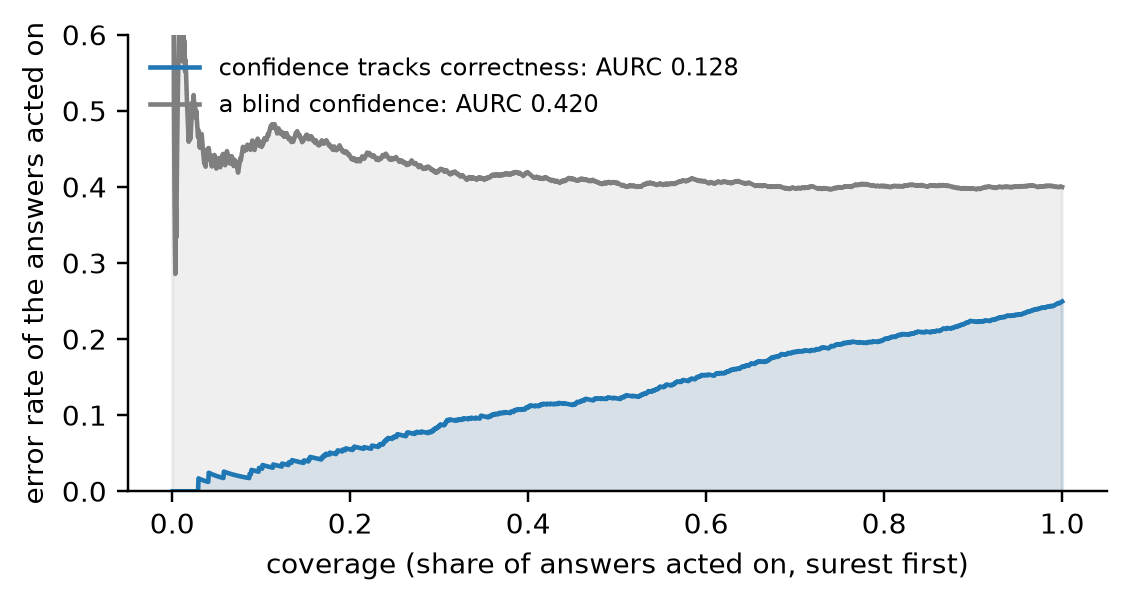

In [ ]:
#| code-fold: true
#| code-summary: figure code
fig, ax = plt.subplots(figsize=(5.2, 2.8))
for q, name, color in ((sure, "confidence tracks correctness", "C0"), (unsure, "a blind confidence", "C7")):
    cv = coverage_curve(selection_scores(q), q.right)
    ax.plot(cv["coverage"], 1 - cv["accuracy"], color=color, lw=1.5, label=f"{name}: AURC {aurc(q):.3f}")
    ax.fill_between(cv["coverage"], 0, 1 - cv["accuracy"], color=color, alpha=0.12)
ax.set(xlabel="coverage (share of answers acted on, surest first)", ylabel="error rate of the answers acted on", ylim=(0, 0.6))
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

## Metric

Any function of a `Preds` is a metric, and its name names the column it fills. `Metric` wraps one when it needs more than that:

- It binds arguments, like `Metric(f1_score, average="weighted")`.
- It keeps the metric to one kind of question, like `Metric(accuracy, qtype="noul")`, which is `decision_metrics`' `accuracy_noul`.
- It composes a name from the function and any argument that differs from its default, so two variants of a metric get two columns.

The CamelCase constructors are fastai's names for the metrics that take arguments: `F1Score`, `FBeta`, `Precision`, `Recall`, `BalancedAccuracy`, `MatthewsCorrCoef`, `CohenKappa`. `skm_to_sysone` is fastai's `skm_to_fastai`. It turns a scikit-learn metric, `func(y_true, y_pred)`, or with `proba=True` `func(y_true, probabilities)`, into a sysone one, computed per question and averaged.

In [ ]:
#| export
def _metric_name(func, kwargs:dict) -> str:
    "The function's name, then the value of every argument that differs from its default"
    sig = inspect.signature(func).parameters
    return "_".join([func.__name__] + [str(v) for k, v in kwargs.items() if k not in sig or sig[k].default != v])

class Metric:
    "A metric of a `Preds`: `func` with its arguments bound, over the rows of one question type when `qtype` is given, reported as `name`"
    def __init__(self, func, name:str|None=None, qtype:str|None=None, **kwargs):
        if isinstance(func, Metric):              # a metric kept to one kind of question keeps its name, with the kind after it
            if name is None: name = func.name + (f"_{qtype}" if qtype is not None and func.qtype is None else "")
            func, kwargs, qtype = func.func, func.kwargs | kwargs, qtype or func.qtype
        if qtype is not None and qtype not in QTYPES: raise ValueError(f"qtype must be one of {list(QTYPES)}, not {qtype!r}")
        self.func, self.qtype, self.kwargs = func, qtype, kwargs
        self.name = name or (_metric_name(func, kwargs) + (f"_{qtype}" if qtype else ""))
    def __call__(self, p:Preds) -> float:
        return float(self.func(p.of_type(self.qtype) if self.qtype is not None else p, **self.kwargs))
    def __repr__(self): return f"Metric({self.name})"

def as_metric(m) -> Metric:
    "A `Metric` from a metric or a plain function of a `Preds`"
    return m if isinstance(m, Metric) else Metric(m)

def F1Score(average:str="macro") -> Metric: "fastai's name: `f1_score`"; return Metric(f1_score, average=average)
def FBeta(beta:float, average:str="macro") -> Metric: "fastai's name: `fbeta`"; return Metric(fbeta, beta=beta, average=average)
def Precision(average:str="macro") -> Metric: "fastai's name: `precision`"; return Metric(precision, average=average)
def Recall(average:str="macro") -> Metric: "fastai's name: `recall`"; return Metric(recall, average=average)
def BalancedAccuracy() -> Metric: "fastai's name: `balanced_accuracy`"; return Metric(balanced_accuracy)
def MatthewsCorrCoef() -> Metric: "fastai's name: `matthews_corrcoef`"; return Metric(matthews_corrcoef)
def CohenKappa(weights:str|None=None) -> Metric: "fastai's name: `cohen_kappa`"; return Metric(cohen_kappa, weights=weights)

def skm_to_sysone(func, proba:bool=False, name:str|None=None, qtype:str|None=None, **kwargs) -> Metric:
    "A scikit-learn style metric `func(y_true, y_pred, **kwargs)` as a `Metric`, computed per question and averaged; with `proba` it gets each row's option probabilities instead of its answer"
    def f(p):
        vals = [func(p.labels[g], p.probs[g][:, :int(p.k[g].max())] if proba else p.pred[g], **kwargs) for g in _groups(p, p.ok) if g.any()]
        return float(np.mean(vals)) if vals else float("nan")
    f.__name__ = name or getattr(func, "__name__", "metric")
    return Metric(f, qtype=qtype)

In [ ]:
test_eq([as_metric(m).name for m in (accuracy, Metric(top_k_accuracy, k=3), F1Score(), F1Score("weighted"), FBeta(2), CohenKappa("quadratic"),
                                     Metric(accuracy, qtype="noul"), Metric(ece, "ece_10_bins", bins=10))],
        ["accuracy", "top_k_accuracy_3", "f1_score", "f1_score_weighted", "fbeta_2", "cohen_kappa_quadratic", "accuracy_noul", "ece_10_bins"])
test_close(Metric(accuracy, qtype="noul")(rp), dm["accuracy_noul"])
test_eq(Metric(CohenKappa("quadratic"), qtype="score").name, "cohen_kappa_quadratic_score")
test_fail(lambda: Metric(accuracy, qtype="yes-no"), contains="qtype must be")
def hits(y_true, y_pred): return float((y_true == y_pred).mean())                   # a scikit-learn style function
test_close(skm_to_sysone(hits)(perfect), 1.0)
test_eq(skm_to_sysone(hits, name="hit_rate").name, "hit_rate")

`metrics_table` reports metrics as a table, over every row and, with `by`, per question type, per question id, or per any label of the rows. With no metrics named, it reports accuracy, macro-F1, log loss, Brier and ECE:

In [ ]:
#| export
DEFAULT_METRICS = (accuracy, f1_score, log_loss, brier_score, ece)

def metrics_table(p:Preds, metrics=None, by=None):
    "A DataFrame of metrics: a row over all rows, and with `by` ('qtype', 'qid' or one label per row) a row per group"
    import pandas as pd
    ms = [as_metric(m) for m in (metrics or DEFAULT_METRICS)]
    row = lambda q: {m.name: m(q) for m in ms} | {"rows": int(q.ok.sum())}
    out = {"all": row(p)}
    if by is not None:
        labels = np.array([QTYPE_NAMES[int(t)] for t in p.qtypes]) if isinstance(by, str) and by == "qtype" else \
                 p.qids if isinstance(by, str) and by == "qid" else np.asarray([str(x) for x in by])
        for g in sorted(set(labels.tolist())): out[g] = row(p.select(labels == g))
    return pd.DataFrame(out).T.astype({"rows": int})

In [ ]:
metrics_table(rp, [accuracy, F1Score(), BalancedAccuracy(), log_loss, ece, score_mae, noul_auroc, aurc], by="qtype").round(3)

,accuracy,f1_score,balanced_accuracy,log_loss,ece,score_mae,noul_auroc,aurc,rows
all,0.334,0.271,0.282,1.932,0.344,1.024,0.469,0.655,374
choice,0.200,0.168,0.199,2.371,0.414,NaN,NaN,0.814,115
noul,0.496,0.506,0.524,1.520,0.355,NaN,0.469,0.613,139
score,0.275,0.252,0.275,1.990,0.281,1.024,NaN,0.744,120


## From any backend's answers

`Preds.from_answers` builds a `Preds` from records with gold and the answers a backend gave them in the Jev schema: a sysone `Decider`, a zero-shot decider, a GLiNER2 decider or Laya's runtime. It reads each answer back with `answer_probs`, the core's [generic function](00_core.ipynb#the-answer-schema) on the question's kind. Every metric above then applies to any backend, and on the answers of the fixture's model the shared ones agree with `answer_metrics`:

In [ ]:
#| export
@patch(cls_method=True)
def from_answers(cls:Preds, records, answers) -> Preds:
    "The `Preds` of answers in the Jev schema to records with gold: any backend's answers, ready for the metrics"
    rows = []
    for i, (r, ans) in enumerate(zip(records, answers)):
        r = load_record(r)
        for qid, qd in r["questions"].items():
            gold, a = (r.get("gold") or {}).get(qid), (ans or {}).get(qid)
            q = Question.from_dict(qd, name=qid)
            ok = q.answerable(gold)
            if ok < 0 or a is None: continue
            t, label = q.target(gold) if ok == 1 else ([0.0] * q.k, -1)
            act = a["action"].get("act_probability") if isinstance(a.get("action"), dict) else None
            rows.append((np.log(np.clip(answer_probs(q, a), 1e-12, 1)), t, q.qtype, label, ok, act, qid, i, [str(k) for k in q.keys]))
    K = max((len(r[0]) for r in rows), default=1)
    pad = lambda v, c: np.pad(np.asarray(v, np.float64), (0, K - len(v)), constant_values=c)
    col = lambda j: [r[j] for r in rows]
    acts = col(5)
    return cls(np.stack([pad(r[0], -1e4) for r in rows]) if rows else np.zeros((0, K)), np.stack([pad(r[1], 0.0) for r in rows]) if rows else np.zeros((0, K)),
               np.stack([np.arange(K) < len(r[0]) for r in rows]) if rows else np.zeros((0, K), bool), col(2), col(3), answerable=col(4),
               act=acts if rows and all(a is not None for a in acts) else None, qids=col(6), case_idx=col(7), option_keys=col(8))

In [ ]:
from sysone.data import TypedDecisions
from sysone.learner import decision_learner

In [ ]:
recs = [json.loads(l) for l in Path("fixtures/typed_decisions_tiny.jsonl").read_text().splitlines()]
data = TypedDecisions.from_records(recs, calib=0)
torch.manual_seed(0)
learn = decision_learner(data, "fixtures/tiny-modernbert", train="head", preset="cpu", loss="soft_ce", calibrate_after_fit=False)
learn.fit(2, lr=3e-3)
answers = [learn.predict(r["state"], r["questions"]) for r in recs]
pa = Preds.from_answers(recs, answers)
am = answer_metrics([(r["questions"], a, r["gold"]) for r, a in zip(recs, answers)])
for k, f in {"accuracy": accuracy, "soft_accuracy": soft_accuracy, "brier": brier_score, "kl": kl_div, "tv": tv_distance, "ece": ece,
             "score_mae": score_mae, "within_one": within_one, "macro_f1": f1_score}.items(): test_close(f(pa), am[k], eps=1e-6)
pa, pa.option_keys[0]

{'loss': '1.184', 'grad_norm': '0.3163', 'learning_rate': '0.003', 'epoch': '0.7692'}
{'loss': '1.28', 'grad_norm': '0.2842', 'learning_rate': '0.003', 'epoch': '1.538'}
{'train_runtime': '0.7053', 'train_samples_per_second': '283.6', 'train_steps_per_second': '36.87', 'train_loss': '1.22', 'epoch': '2'}


100%|##########| 26/26 [00:00<00:00, 36.86it/s]


(Preds(100 rows: 30 choice, 40 score, 30 noul · 0 unanswerable · T = 1),
 ['continue', 'human_review', 'observe', 'stop'])

## Which metric for what

| metric | reads | rows it counts |
| --- | --- | --- |
| `accuracy`, `error_rate` | each row's answer | every answerable row |
| `top_k_accuracy` | the options' ranking | choice and score rows |
| `precision`, `recall`, `f1_score`, `fbeta`, `balanced_accuracy`, `matthews_corrcoef`, `cohen_kappa` | answers, by class | per question, then averaged |
| `log_loss` | the probabilities against the gold distribution | every answerable row |
| `brier_score`, `soft_accuracy`, `kl_div`, `tv_distance` | the probabilities against the gold distribution | choice and noul rows |
| `ece`, `mce` | the answer's probability against being right | every answerable row |
| `score_mae`, `within_one`, `rps`, `cohen_kappa(weights="quadratic")` | the levels | score rows |
| `noul_auroc` | p(true) | noul rows |
| `aurc`, `accuracy_at_coverage`, `coverage_at_accuracy`, `act_auroc` | a score to act on: confidence or p(act) | every row; acting on an unanswerable one is an error |

The [learner](05_learner.ipynb#metrics) takes them as `metrics=[...]`, [`evaluate`](09_evaluate.ipynb) takes them for any backend, and [interpret](09a_interpret.ipynb) puts them beside the confusions and the worst cases.